# Gaussian Anomaly Detection (From Scratch)

In this notebook, we implement an anomaly detection system using a Gaussian
(probabilistic) model. The algorithm learns the distribution of normal data
and identifies anomalies as points with very low probability.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

X_train = np.random.normal(loc=0, scale=1, size=(300, 2))

In [3]:
X_anomalies = np.array([
    [6, 6],
    [-6, -6],
    [5, -5],
    [-5, 5]
])

X_test = np.vstack([X_train, X_anomalies])

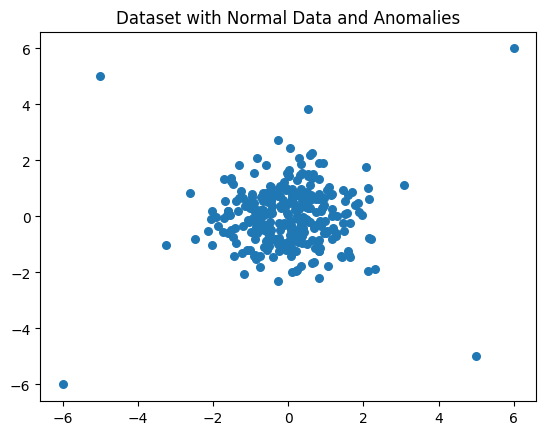

In [4]:
plt.scatter(X_test[:, 0], X_test[:, 1], s=30)
plt.title("Dataset with Normal Data and Anomalies")
plt.show()

## Gaussian Anomaly Detection Intuition

Normal data follows a Gaussian distribution.
Anomalies lie in low-probability regions.

We compute:
- Mean (μ)
- Variance (σ²)
- Probability density p(x)

In [5]:
def estimate_gaussian(X):
    mu = np.mean(X, axis=0)
    sigma2 = np.var(X, axis=0)
    return mu, sigma2

In [6]:
def gaussian_pdf(X, mu, sigma2):
    coeff = 1 / np.sqrt(2 * np.pi * sigma2)
    exponent = np.exp(-((X - mu) ** 2) / (2 * sigma2))
    return np.prod(coeff * exponent, axis=1)

In [7]:
mu, sigma2 = estimate_gaussian(X_train)

p_values = gaussian_pdf(X_test, mu, sigma2)
epsilon = np.percentile(p_values, 5)


In [8]:
anomalies = X_test[p_values < epsilon]


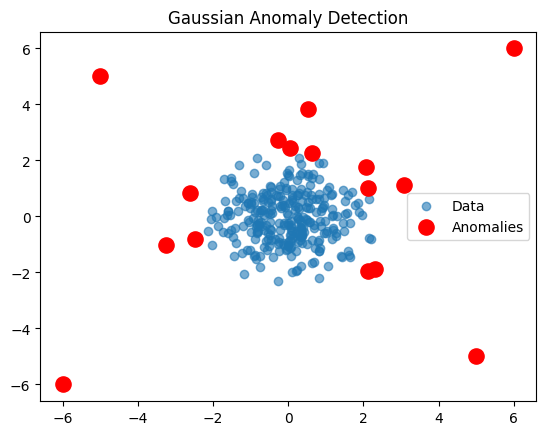

In [9]:
plt.scatter(X_test[:, 0], X_test[:, 1], label="Data", alpha=0.6)
plt.scatter(anomalies[:, 0], anomalies[:, 1],
            c="red", s=120, label="Anomalies")
plt.legend()
plt.title("Gaussian Anomaly Detection")
plt.show()

## Gaussian vs K-Means for Anomaly Detection

K-Means:
- Distance-based
- Assumes spherical clusters

Gaussian Model:
- Probability-based
- Handles skewed distributions
- More principled statistically